In [1]:

from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Future Sales:
[1272868.68190909 1270876.22643996 1268883.77097084 1266891.31550171
 1264898.86003258 1262906.40456346 1260913.94909433 1258921.4936252
 1256929.03815608 1254936.58268695 1252944.12721782 1250951.67174869
 1248959.21627957 1246966.76081044 1244974.30534131 1242981.84987219
 1240989.39440306 1238996.93893393 1237004.48346481 1235012.02799568
 1233019.57252655 1231027.11705743 1229034.6615883  1227042.20611917
 1225049.75065004 1223057.29518092 1221064.83971179 1219072.38424266
 1217079.92877354 1215087.47330441]


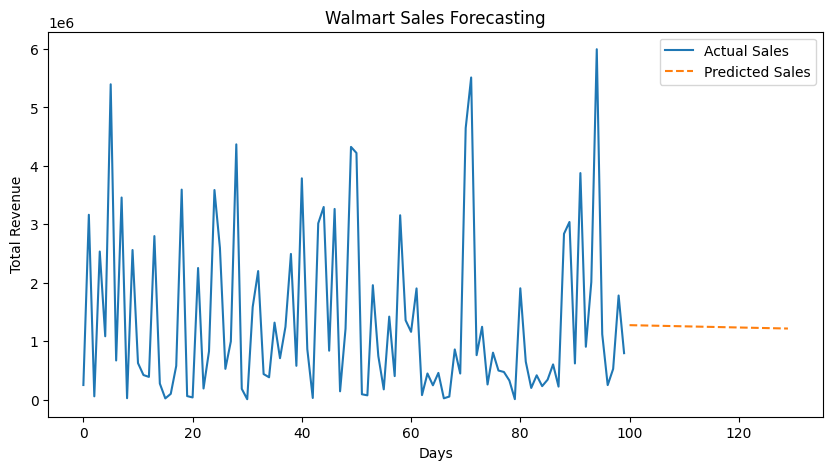

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import os

# Load dataset
df = pd.read_csv("sales.csv")

# Select needed columns
df = df[['Order Date', 'Total Revenue']]

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%m/%d/%Y")

# Sort data
df = df.sort_values('Order Date')

# Group weekly sales by date
sales_data = df.groupby('Order Date')['Total Revenue'].sum().reset_index()

# Create day numbers
sales_data['Day_Number'] = range(len(sales_data))

# Input and Output
X = sales_data[['Day_Number']]
y = sales_data['Total Revenue']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 30 days
future_days = np.arange(
    len(sales_data),
    len(sales_data)+30
).reshape(-1,1)

future_sales = model.predict(future_days)

# Print predictions
print("Predicted Future Sales:")
print(future_sales)

# Plot graph
plt.figure(figsize=(10,5))

# Actual Sales
plt.plot(
    sales_data['Day_Number'],
    sales_data['Total Revenue'],
    label='Actual Sales'
)

# Forecast
plt.plot(
    future_days,
    future_sales,
    linestyle='--',
    label='Predicted Sales'
)

plt.xlabel("Days")
plt.ylabel("Total Revenue")
plt.title("Walmart Sales Forecasting")
plt.legend()

# Create directory if it doesn't exist
os.makedirs("FUTURE_ML_01/images", exist_ok=True)

# Save image
plt.savefig("FUTURE_ML_01/images/sales_trend.png")

# Show graph
plt.show()

In [5]:
with open("FUTURE_ML_01/requirements.txt", "w") as f:
    f.write(
        "pandas\n"
        "numpy\n"
        "matplotlib\n"
        "scikit-learn\n"
    )

In [6]:

readme_text = """
# Sales & Demand Forecasting using Walmart Dataset

## Project Overview
This project predicts future Walmart sales using Machine Learning.

## Dataset
Walmart Sales Dataset

## Algorithm Used
Linear Regression

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Output
- Sales forecasting graph
- Future sales prediction

## Project Structure
FUTURE_ML_01/
│
├── data/
├── images/
│   └── sales_trend.png
├── requirements.txt
└── README.md
"""

with open("FUTURE_ML_01/README.md", "w") as f:
    f.write(readme_text)
